In [27]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import json
import networkx as nx
from difflib import get_close_matches
from scipy.stats import chi2_contingency
import numpy as np
import seaborn as sns
import unicodedata
import re

# Liste actor

In [2]:
# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

#print("Path to dataset files:", path)
#print("Fichiers dans le dossier :")
#print(os.listdir(path))

file_path_movie = os.path.join(path, "tmdb_5000_movies.csv")
file_path_credits = os.path.join(path, "tmdb_5000_credits.csv")

movies   = pd.read_csv(file_path_movie)
credits  = pd.read_csv(file_path_credits)

# Vérifier les colonnes
#print(credits.columns)
#print(movies.columns)

# Faire la jointure sur movie_id (credits) et id (movies)
data = movies.merge(credits, left_on='id', right_on='movie_id', how='inner')

"""print(data.shape)
col = data.columns.tolist()
for i in range(0, len(col), 5) :
    if (i + 5 <= len(col)) :
        print(col[i : i + 5])
    else :
        print(col[i:])
print(data.head())"""

'print(data.shape)\ncol = data.columns.tolist()\nfor i in range(0, len(col), 5) :\n    if (i + 5 <= len(col)) :\n        print(col[i : i + 5])\n    else :\n        print(col[i:])\nprint(data.head())'

In [3]:
def get_top_actors(cast_json, nbr) :
    try :
        cast_list = json.loads(cast_json)
        top = [actor['name'] for actor in cast_list]
        while len(top) < nbr :
            top.append(None)
        return top[:nbr]
    except :
        return [None] * nbr

def get_imdb_graph(data, nbr_actors=3, firstyear=1, lastyear=3000, genre=None, minscore=0, maxscore=10) :

    df = data.copy()

    # Filtre par genre
    if genre is not None:
        df = df[df['genres'].str.contains(genre, na=False)]

    # S'assurer que release_date est bien en datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    # Extraire l'année
    df['release_year'] = df['release_date'].dt.year
    # Filtre par année et score
    df = df[(df['release_year'] >= firstyear) &
            (df['release_year'] <= lastyear) &
            (df['vote_average'] >= minscore) &
            (df['vote_average'] <= maxscore)]

    # Sélection des colonnes utiles
    df = df[['original_title', 'cast', 'release_year']]

    # Garder seulement les lignes où 'cast' contient au moins nbr_actors acteurs
    #df = df[df['cast'].apply(lambda x: len(json.loads(x)) >= nbr_actors)]

    # Une seule colonne 'actors' contenant une liste
    df['actors'] = df['cast'].apply(lambda x: get_top_actors(x, nbr_actors))

    # Création du graphe
    G = nx.Graph()

    for _, row in df.iterrows() :
        # Retirer les valeurs None de la liste
        actors = [a for a in row['actors'] if pd.notna(a)]

        # Ajouter toutes les combinaisons d'acteurs
        if len(actors) >= 2 :
            for i in range(len(actors)) :
                for j in range(i + 1, len(actors)) :
                    G.add_edge(actors[i], actors[j])

    return G

In [4]:
G = get_imdb_graph(data, nbr_actors=10, firstyear=1990, lastyear=2009)

print("\tNombre d'acteurs :", G.number_of_nodes())
print("\tNombre de collaborations :", G.number_of_edges())

	Nombre d'acteurs : 11637
	Nombre de collaborations : 111299


# MBTI

In [6]:
path_mbti = kagglehub.dataset_download("yuraslastya/celeb-mbti")

print("Path to dataset files :", path_mbti)
print("Fichiers dans le dossier :")
print(os.listdir(path_mbti))

Path to dataset files : C:\Users\dav-9\.cache\kagglehub\datasets\yuraslastya\celeb-mbti\versions\1
Fichiers dans le dossier :
['mbti_celebrities.csv']


In [7]:
file_path_mbti = os.path.join(path_mbti, "mbti_celebrities.csv")

mbti = pd.read_csv(file_path_mbti)

print(mbti.shape)
# Vérifier les colonnes
print("=== Colonnes ===")
print(mbti.columns.tolist())

print("\n=== Aperçu ===")
print(mbti.head().to_string())



(50878, 32)
=== Colonnes ===
['id', 'name', 'cat_id', 'category', 'sub_cat_id', 'subcategory', 'four_letter', 'four_letter_total_voted', 'enneagram', 'enneagram_total_voted', 'socionics', 'socionics_total_voted', 'instinctual_variant', 'instinctual_variant_total_voted', 'tritype', 'tritype_total_voted', 'temperaments', 'temperaments_total_voted', 'attitudinal_psyche', 'attitudinal_psyche_total_voted', 'big_5_SLOAN', 'big_5_SLOAN_total_voted', 'classic_jungian', 'classic_jungian_total_voted', 'letter_1', 'letter_1_percentage', 'letter_2', 'letter_2_percentage', 'letter_3', 'letter_3_percentage', 'letter_4', 'letter_4_percentage']

=== Aperçu ===
      id           name  cat_id category  sub_cat_id subcategory four_letter  four_letter_total_voted enneagram  enneagram_total_voted socionics  socionics_total_voted instinctual_variant  instinctual_variant_total_voted  tritype  tritype_total_voted           temperaments  temperaments_total_voted attitudinal_psyche  attitudinal_psyche_total_vo

In [8]:
cols = ['name', 'category', 'subcategory', 'four_letter', 'letter_1', 'letter_1_percentage',
    'letter_2', 'letter_2_percentage', 'letter_3', 'letter_3_percentage', 'letter_4', 'letter_4_percentage']

mbti = mbti[cols]

print(mbti.shape)
print(mbti.head().to_string())

(50878, 12)
            name category subcategory four_letter letter_1  letter_1_percentage letter_2  letter_2_percentage letter_3  letter_3_percentage letter_4  letter_4_percentage
0    Derek Jeter   Sports    Baseball        ISTJ        I                 0.70        S                 0.95        T                 0.84        J                 0.73
1  Ichiro Suzuki   Sports    Baseball        ISTP        I                 1.00        S                 0.97        T                 0.97        P                 0.74
2   Trevor Bauer   Sports    Baseball        ENTP        E                 0.62        N                 0.95        T                 0.95        P                 0.98
3   Zack Greinke   Sports    Baseball        INTP        I                 1.00        N                 0.97        T                 1.00        P                 0.81
4      Babe Ruth   Sports    Baseball        ESTP        E                 0.96        S                 0.92        T                 0.9

#### Doublon ?

In [9]:
print(f"Nombre de lignes avant nettoyage : {len(mbti)}")

mbti = mbti.drop_duplicates()

print(f"Nombre de lignes après nettoyage : {len(mbti)}")

Nombre de lignes avant nettoyage : 50878
Nombre de lignes après nettoyage : 50791


In [10]:
doublons = mbti[mbti.duplicated('name', keep=False)]
print(doublons['name'].value_counts())

name
Francesco Borromini    3
Reggie Jackson         2
James Paxton           2
Carlos Santana         2
Matt Chapman           2
                      ..
Perun                  2
Morana                 2
Mike Dean              2
Mani                   2
Philip II of France    2
Name: count, Length: 150, dtype: int64


In [11]:
print(doublons.sort_values(by='name').to_string())

                                  name     category                           subcategory four_letter letter_1  letter_1_percentage letter_2  letter_2_percentage letter_3  letter_3_percentage letter_4  letter_4_percentage
10124                                .   Noteworthy                             Criminals        ISTP        I                 1.00        S                 1.00        T                 1.00        P                 1.00
12294                                .     Business                              Business        INFP        I                 1.00        N                 1.00        F                 1.00        P                 1.00
50847                  Abraham Lincoln     Internet          Characters of Brandon Rogers        INTP        I                 1.00        N                 1.00        T                 1.00        P                 1.00
688                    Abraham Lincoln    Political                 Presidents of the USA        INTP        I  

In [12]:
print("Distribution 4 lettres :")
for name, count in mbti['four_letter'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(mbti) *100:.1f}%)")

Distribution 4 lettres :
	ENFP : 5465 (10.8%)
	ENTP : 4659 (9.2%)
	INFP : 3776 (7.4%)
	ESFP : 3619 (7.1%)
	INFJ : 3578 (7.0%)
	ISFP : 3392 (6.7%)
	INTP : 3371 (6.6%)
	ENFJ : 3247 (6.4%)
	ESTP : 2847 (5.6%)
	INTJ : 2732 (5.4%)
	ESFJ : 2643 (5.2%)
	ISTP : 2508 (4.9%)
	ENTJ : 2402 (4.7%)
	ISTJ : 2255 (4.4%)
	ISFJ : 2243 (4.4%)
	ESTJ : 2054 (4.0%)


### Distribution des lettres

- La première lettre est un I pour Introverti ou un E pour extraverti
- La deuxième lettre est un S pour Sensation ou un N pour intuition
- La troisième lettre est un T pour réflexif (Thinking) ou un F pour sentimental (feeling)
- La quatrième et dernière lettre est un J pour Jugement ou un P pour Perception

In [13]:
print("Distribution 1ere lettre (I/E) :")
for name, count in mbti['letter_1'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(mbti) *100:.1f}%)")

print("\nDistribution 2eme lettre (N/S) :")
for name, count in mbti['letter_2'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(mbti) *100:.1f}%)")

print("\nDistribution 2eme lettre (F/T) :")
for name, count in mbti['letter_3'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(mbti) *100:.1f}%)")

print("\nDistribution 4eme lettre (P/J) :")
for name, count in mbti['letter_4'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(mbti) *100:.1f}%)")

Distribution 1ere lettre (I/E) :
	E : 26936 (53.0%)
	I : 23855 (47.0%)

Distribution 2eme lettre (N/S) :
	N : 29230 (57.5%)
	S : 21561 (42.5%)

Distribution 2eme lettre (F/T) :
	F : 27963 (55.1%)
	T : 22828 (44.9%)

Distribution 4eme lettre (P/J) :
	P : 29637 (58.4%)
	J : 21154 (41.6%)


### Analyse indépendance

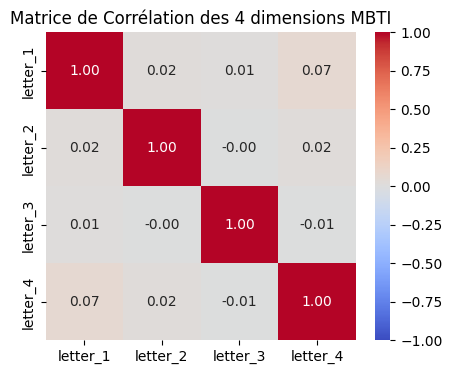

In [14]:
# 1. Définir le mapping pour transformer les lettres en chiffres (0 ou 1)
mapping = {'letter_1': {'E': 1, 'I': 0},
            'letter_2': {'N': 1, 'S': 0},
            'letter_3': {'F': 1, 'T': 0},
            'letter_4': {'P': 1, 'J': 0}}

# 2. Créer une copie des colonnes pour le calcul
mbti_numeric = mbti[['letter_1', 'letter_2', 'letter_3', 'letter_4']].copy()

# Appliquer le mapping
for col, map_dict in mapping.items() :
    mbti_numeric[col] = mbti_numeric[col].map(map_dict)

# 3. Calculer la matrice de corrélation
corr_matrix = mbti_numeric.corr()

# 4. Affichage avec une Heatmap (carte de chaleur)
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Matrice de Corrélation des 4 dimensions MBTI")
plt.show()

**Evaluation :**

*Valeur p :*

>H₀ (hypothèse nulle) : les variables sont indépendantes
>
>Avec beaucoup de données, même une relation faible → p-value ≈ 0
>
>p ≤ 0.05 → on rejette H₀ → les variables sont probablement dépendantes
>
>p > 0.05 → on ne rejette pas H₀ → pas de preuve de dépendance

*V de Cramér :*

>0 → aucune association
>
>1 → association parfaite

In [15]:
def cramers_v(contingency_table, chi2) :
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    # Formule simplifiée pour du 2x2
    return np.sqrt(phi2 / min(k - 1, r - 1))

dims = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

for i in range(len(dims)) :
    for j in range(i+1, len(dims)) :
        contingency_table = pd.crosstab(mbti[dims[i]], mbti[dims[j]])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        v = cramers_v(contingency_table, chi2)
        print(f"Test Chi2 {dims[i]}-{dims[j]} | p-value: {p:.4f} | V de Cramér: {v:.4f}")

        #print(f"Test Chi2 entre Lettre {i+1} et {j+1} - p-value : {p:.4f}")

Test Chi2 letter_1-letter_2 | p-value: 0.0000 | V de Cramér: 0.0216
Test Chi2 letter_1-letter_3 | p-value: 0.0101 | V de Cramér: 0.0114
Test Chi2 letter_1-letter_4 | p-value: 0.0000 | V de Cramér: 0.0698
Test Chi2 letter_2-letter_3 | p-value: 0.6378 | V de Cramér: 0.0021
Test Chi2 letter_2-letter_4 | p-value: 0.0001 | V de Cramér: 0.0173
Test Chi2 letter_3-letter_4 | p-value: 0.2457 | V de Cramér: 0.0052


### Some informations

In [16]:
# Liste d'acteurs à rechercher
actors_to_find = ["Frankie Muniz", "Samuel L. Jackson"]

result = mbti[mbti['name'].isin(actors_to_find)]
print(result.to_string())

                   name     category                 subcategory four_letter letter_1  letter_1_percentage letter_2  letter_2_percentage letter_3  letter_3_percentage letter_4  letter_4_percentage
820   Samuel L. Jackson  Pop Culture  Actors and Actresses (USA)        ESTP        E                 0.98        S                 0.89        T                 0.96        P                 0.90
1358      Frankie Muniz  Pop Culture  Actors and Actresses (USA)        ENFP        E                 0.87        N                 0.83        F                 0.91        P                 0.91


### DB MBTI with actors only

In [17]:
# Filtrer uniquement les acteurs (category == 'Pop Culture' et subcategory contenant 'Actor')
actors_mbti = mbti[mbti['subcategory'].str.contains('Actor', na=False)]

print(f"Nombre d'acteurs dans la db MBTI : {len(actors_mbti):,}")
print(actors_mbti['subcategory'].value_counts())

Nombre d'acteurs dans la db MBTI : 6,914
subcategory
Actors and Actresses (USA)             2426
Actors & Actresses (Asia)              1656
Actors & Actresses (Europe)             822
Actors and Actresses (UK & Ireland)     801
Actors & Actresses (Latin America)      502
Actors & Actresses (World)              341
Actors & Actresses (Canada)             223
Actors & Actresses (Oceania)            143
Name: count, dtype: int64


In [20]:
print("Distribution 4 lettres :")
for name, count in actors_mbti['four_letter'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(actors_mbti) *100:.1f}%)")

print("\nDistribution 1ere lettre (I/E) :")
for name, count in actors_mbti['letter_1'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(actors_mbti) *100:.1f}%)")

print("\nDistribution 2eme lettre (N/S) :")
for name, count in actors_mbti['letter_2'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(actors_mbti) *100:.1f}%)")

print("\nDistribution 2eme lettre (F/T) :")
for name, count in actors_mbti['letter_3'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(actors_mbti) *100:.1f}%)")

print("\nDistribution 4eme lettre (P/J) :")
for name, count in actors_mbti['letter_4'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(actors_mbti) *100:.1f}%)")

Distribution 4 lettres :
	ENFP : 1016 (14.7%)
	ENFJ : 645 (9.3%)
	INFJ : 581 (8.4%)
	INFP : 565 (8.2%)
	ISFP : 551 (8.0%)
	ENTP : 537 (7.8%)
	ESFJ : 524 (7.6%)
	ESFP : 517 (7.5%)
	ISFJ : 366 (5.3%)
	ESTP : 355 (5.1%)
	ISTP : 306 (4.4%)
	INTP : 243 (3.5%)
	ENTJ : 195 (2.8%)
	INTJ : 180 (2.6%)
	ISTJ : 180 (2.6%)
	ESTJ : 153 (2.2%)

Distribution 1ere lettre (I/E) :
	E : 3942 (57.0%)
	I : 2972 (43.0%)

Distribution 2eme lettre (N/S) :
	N : 3962 (57.3%)
	S : 2952 (42.7%)

Distribution 2eme lettre (F/T) :
	F : 4765 (68.9%)
	T : 2149 (31.1%)

Distribution 4eme lettre (P/J) :
	P : 4090 (59.2%)
	J : 2824 (40.8%)


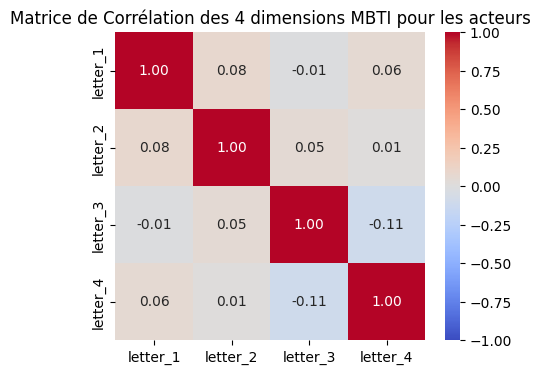

In [21]:
# 1. Définir le mapping pour transformer les lettres en chiffres (0 ou 1)
mapping = {'letter_1': {'E': 1, 'I': 0},
            'letter_2': {'N': 1, 'S': 0},
            'letter_3': {'F': 1, 'T': 0},
            'letter_4': {'P': 1, 'J': 0}}

# 2. Créer une copie des colonnes pour le calcul
actors_mbti_numeric = actors_mbti[['letter_1', 'letter_2', 'letter_3', 'letter_4']].copy()

# Appliquer le mapping
for col, map_dict in mapping.items() :
    actors_mbti_numeric[col] = actors_mbti_numeric[col].map(map_dict)

# 3. Calculer la matrice de corrélation
corr_matrix_actors = actors_mbti_numeric.corr()

# 4. Affichage avec une Heatmap (carte de chaleur)
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix_actors, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Matrice de Corrélation des 4 dimensions MBTI pour les acteurs")
plt.show()

In [22]:
def cramers_v(contingency_table, chi2) :
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    # Formule simplifiée pour du 2x2
    return np.sqrt(phi2 / min(k - 1, r - 1))

dims = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

for i in range(len(dims)) :
    for j in range(i+1, len(dims)) :
        contingency_table = pd.crosstab(actors_mbti[dims[i]], actors_mbti[dims[j]])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        v = cramers_v(contingency_table, chi2)
        print(f"Test Chi2 {dims[i]}-{dims[j]} | p-value: {p:.4f} | V de Cramér: {v:.4f}")

        #print(f"Test Chi2 entre Lettre {i+1} et {j+1} - p-value : {p:.4f}")

Test Chi2 letter_1-letter_2 | p-value: 0.0000 | V de Cramér: 0.0789
Test Chi2 letter_1-letter_3 | p-value: 0.4544 | V de Cramér: 0.0090
Test Chi2 letter_1-letter_4 | p-value: 0.0000 | V de Cramér: 0.0550
Test Chi2 letter_2-letter_3 | p-value: 0.0001 | V de Cramér: 0.0480
Test Chi2 letter_2-letter_4 | p-value: 0.4069 | V de Cramér: 0.0100
Test Chi2 letter_3-letter_4 | p-value: 0.0000 | V de Cramér: 0.1076


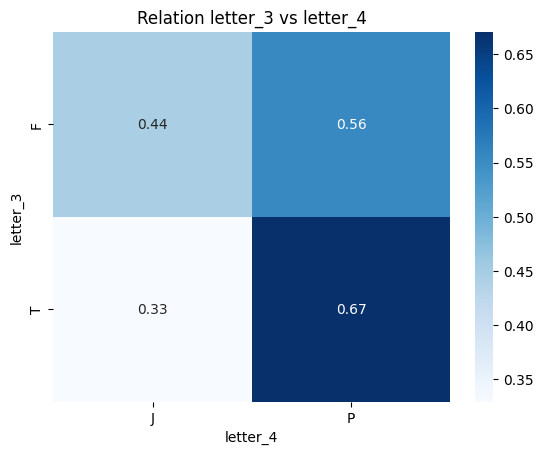

In [23]:
table = pd.crosstab(actors_mbti['letter_3'], actors_mbti['letter_4'], normalize='index')

sns.heatmap(table, annot=True, cmap='Blues')
plt.title("Relation letter_3 vs letter_4")
plt.show()

### Perfect match

In [24]:
# Récupérer les acteurs du graphe
actors_in_graph = set(G.nodes())

# Récupérer les acteurs dans la db MBTI
actors_in_mbti = set(mbti['name'].tolist())

# Intersection : acteurs présents dans les deux
common_actors = actors_in_graph & actors_in_mbti

print(f"Acteurs dans le graphe         : {len(actors_in_graph):,}")
print(f"Célébrités dans MBTI           : {len(actors_in_mbti):,}")
print(f"Acteurs en commun              : {len(common_actors):,}")

Acteurs dans le graphe         : 11,637
Célébrités dans MBTI           : 50,640
Acteurs en commun              : 2,401


In [25]:
# Récupérer les acteurs du graphe
actors_in_graph = set(G.nodes())

# Récupérer les acteurs dans la db MBTI
actors_in_mbti = set(actors_mbti['name'].tolist())

# Intersection : acteurs présents dans les deux
common_actors_2 = actors_in_graph & actors_in_mbti

print(f"Acteurs dans le graphe         : {len(actors_in_graph):,}")
print(f"Célébrités dans MBTI           : {len(actors_in_mbti):,}")
print(f"Acteurs en commun              : {len(common_actors_2):,}")

Acteurs dans le graphe         : 11,637
Célébrités dans MBTI           : 6,912
Acteurs en commun              : 1,912


In [26]:
difference = common_actors - common_actors_2
actors_to_find = []
print(len(difference))
print()
for i in list(difference) :
    actors_to_find.append(i)

result = mbti[mbti['name'].isin(actors_to_find)]
print(len(result['subcategory'].value_counts()))
print()
for name, count in result['subcategory'].value_counts().items():
    print(f"{name} : {count}")
#print(result[:10].to_string())

489

62

Comedians : 94
People of Classic Hollywood : 63
Voice Acting : 55
Film Directors : 49
Hosts & Presenters : 25
Models : 19
Writers (Literature, Modern) : 13
Basketball : 11
Film & TV Crew : 9
News & Journalists : 8
Classic Pop & Contemporary : 8
Football (American) : 8
Government (USA) : 7
Criminals : 6
Artists (Animators) : 6
Wrestling : 6
European, Musicians : 6
Martial Arts : 5
Baseball : 5
Business : 4
Historical Figures (1900s) : 4
Latin American, Musicians : 4
MMA : 4
Boxing : 4
Presidents of the USA : 4
Artists : 3
Football (Soccer) : 3
Famous For Being Famous : 3
Political Commentators : 3
Performers : 3
Internet Personalities (Other) : 3
General Vloggers : 3
Skateboarding : 3
Brazil, Musicians : 3
Physics & Astronomy : 3
Writers (Comics) : 2
Wrestling (The Performers) : 2
Activists : 2
Skiing & Snowboarding : 2
Tennis : 2
Mathematics : 2
Psychology & Neuroscience : 2
Classical : 2
Kpop : 2
Hockey : 1
Government (World) : 1
Culinary Arts : 1
People of Law : 1
Ice skatin

### Match even if not perfect

Avec normalisation = pas ouf

In [28]:
def normalize(name):
    # minuscules
    name = name.lower()
    
    # enlever accents
    name = unicodedata.normalize('NFKD', name).encode('ascii', 'ignore').decode('utf-8')
    
    # enlever ponctuation
    name = re.sub(r'[^a-z\s]', '', name)
    
    # trim espaces
    name = re.sub(r'\s+', ' ', name).strip()
    
    return name

# Récupérer les acteurs du graphe
actors_in_graph = set(G.nodes())
# Récupérer les acteurs dans la db MBTI
actors_in_mbti = set(mbti['name'].tolist())
# Intersection : acteurs présents dans les deux
common_actors = actors_in_graph & actors_in_mbti

# Pour chaque acteur du graphe, chercher le nom le plus proche dans MBTI

mbti_names = set(mbti['name'].tolist())
mbti_names = list(mbti_names - common_actors) # on enleve les perfect match
mbti_names_norm = []
for name_norm in mbti_names :
    mbti_names_norm.append(normalize(name_norm))
actors_in_graph = actors_in_graph - common_actors # on enleve les perfect match 

mbti['name_norm'] = mbti['name'].apply(normalize)
actors_norm = {normalize(a): a for a in actors_in_graph}

matched = {}

for actor in actors_norm :
    matches = get_close_matches(actor, mbti_names_norm, n=1, cutoff=0.9)
    if matches :
        matched[actor] = matches[0]

print(f"Acteurs matchés (approx)  : {len(matched):,}")
print("\nNoms match :")
for original, match in list(matched.items()) :
    if original != match :
        print(f"  {original:<30} match '{match}'")

Acteurs matchés (approx)  : 278

Noms match :
  david alan grier               match 'david alan gore'
  eric benet                     match 'eric berne'
  anna levine                    match 'janna levin'
  sage ryan                      match 'saige ryan'
  caroline ilea                  match 'caroline leaf'
  john walton                    match 'john dalton'
  lisa chung                     match 'alisa chung'
  megan murphy                   match 'meghan murphy'
  john morris                    match 'john morrison'
  drew pinsky                    match 'drew binsky'
  michael barry                  match 'michael burry'
  red west                       match 'fred west'
  john wood                      match 'john woo'
  jack wilson                    match 'mack wilson'
  dragon                         match 'dagon'
  juan fernandez                 match 'juani fernandez'
  anthony heald                  match 'anthony head'
  joie lee                       match 'joe lee'


In [29]:
# Récupérer les acteurs du graphe
actors_in_graph = set(G.nodes())
# Récupérer les acteurs dans la db MBTI
actors_in_mbti = set(mbti['name'].tolist())
# Intersection : acteurs présents dans les deux
common_actors = actors_in_graph & actors_in_mbti

# Pour chaque acteur du graphe, chercher le nom le plus proche dans MBTI
mbti_names = set(mbti['name'].tolist())
mbti_names = list(mbti_names - common_actors) # on enleve les perfect match
actors_in_graph = actors_in_graph - common_actors # on enleve les perfect match 
matched = {}

for actor in actors_in_graph :
    matches = get_close_matches(actor, mbti_names, n=1, cutoff=0.9)
    if matches :
        matched[actor] = matches[0]

print(f"Acteurs matchés (approx)  : {len(matched):,}")
print("\nNoms match :")
for original, match in list(matched.items()) :
    if original != match :
        print(f"  {original:<30} match '{match}'")

Acteurs matchés (approx)  : 223

Noms match :
  David Alan Grier               match 'David Alan Gore'
  Eric Benet                     match 'Eric Berne'
  Sage Ryan                      match 'Saige Ryan'
  John Walton                    match 'John Dalton'
  Megan Murphy                   match 'Meghan Murphy'
  John Morris                    match 'John Morrison'
  Drew Pinsky                    match 'Drew Binsky'
  George Perez                   match 'George Pérez'
  Michael Barry                  match 'Michael Burry'
  John Wood                      match 'John Woo'
  Jack Wilson                    match 'Mack Wilson'
  Dragon                         match 'Dagon'
  Anthony Heald                  match 'Anthony Head'
  Joie Lee                       match 'Joe Lee'
  Ron Lester                     match 'Jon Lester'
  Nadim Sawalha                  match 'Nadia Sawalha'
  Richard Lobb                   match 'Richard Loeb'
  Sarah Catherine Brooks         match 'Sarah Catherin

In [30]:
def same_person(name1, name2) :
    def normalize(name) :
        # remplacer ., ', ’ et , par des espaces
        name = name.replace('.', ' ').replace(',', ' ').replace('’', ' ').replace("'", ' ')
        
        # enlever les accents
        name = unicodedata.normalize('NFKD', name)
        name = name.encode('ascii', 'ignore').decode('utf-8')
        
        # mettre en minuscule
        name = name.lower()
        
        # enlever les espaces multiples
        name = re.sub(r'\s+', ' ', name)
        
        # trim (espaces début/fin)
        name = name.strip()
        
        return name
    
    return normalize(name1) == normalize(name2)

valid_match = {}
invalid_match = {}
for original, match in list(matched.items()) :
    if same_person(original, match) :
        valid_match[original] = match
    else :
        invalid_match[original] = match

In [31]:
print(f"Acteurs valides : {len(valid_match):,}")
print("\nNoms match :")
for original, match in list(valid_match.items()) :
    print(f"  {original:<30} match '{match}'")

Acteurs valides : 45

Noms match :
  George Perez                   match 'George Pérez'
  Jeroen Krabbé                  match 'Jeroen Krabbe'
  Sônia Braga                    match 'Sonia Braga'
  Alex D. Linz                   match 'Alex D Linz'
  Eduardo Yáñez                  match 'Eduardo Yañez'
  Roman Polanski                 match 'Roman Polański'
  Nikolaj Coster-Waldau          match 'Nikolaj Coster-Waldau '
  Ryunosuke Kamiki               match 'Ryūnosuke Kamiki'
  Patrick J. Adams               match 'Patrick J Adams'
  Zoe Saldana                    match 'Zoe Saldaña'
  Michael Peña                   match 'Michael Pena'
  Carlos Gómez                   match 'Carlos Gomez'
  J.K. Simmons                   match 'J. K. Simmons'
  Colleen O'Shaughnessey         match 'Colleen O’Shaughnessey'
  E.G. Daily                     match 'E. G. Daily'
  J.E. Freeman                   match 'J. E. Freeman'
  Miriam Colón                   match 'Míriam Colón'
  Ken Griffey, Jr.

In [32]:
print(f"Acteurs invalides : {len(invalid_match):,}")
print("\nNoms match :")
for original, match in list(invalid_match.items()) :
    print(f"  {original:<30} match '{match}'")

Acteurs invalides : 178

Noms match :
  David Alan Grier               match 'David Alan Gore'
  Eric Benet                     match 'Eric Berne'
  Sage Ryan                      match 'Saige Ryan'
  John Walton                    match 'John Dalton'
  Megan Murphy                   match 'Meghan Murphy'
  John Morris                    match 'John Morrison'
  Drew Pinsky                    match 'Drew Binsky'
  Michael Barry                  match 'Michael Burry'
  John Wood                      match 'John Woo'
  Jack Wilson                    match 'Mack Wilson'
  Dragon                         match 'Dagon'
  Anthony Heald                  match 'Anthony Head'
  Joie Lee                       match 'Joe Lee'
  Ron Lester                     match 'Jon Lester'
  Nadim Sawalha                  match 'Nadia Sawalha'
  Richard Lobb                   match 'Richard Loeb'
  Sarah Catherine Brooks         match 'Sarah Catherine Hook'
  John Mahoney                   match 'John Money'
  

In [33]:
# Récupérer les acteurs du graphe
actors_in_graph = set(G.nodes())

# convertir en dict inverse
valid_inverse = {v: k for k, v in valid_match.items()}
# Récupérer les acteurs dans la db MBTI
mbti['name_cleaned'] = mbti['name'].replace(valid_inverse)
actors_in_mbti = set(mbti['name_cleaned'].tolist())

# Intersection : acteurs présents dans les deux
common_actors = actors_in_graph & actors_in_mbti

print(f"Acteurs dans le graphe         : {len(actors_in_graph):,}")
print(f"Célébrités dans MBTI           : {len(actors_in_mbti):,}")
print(f"Acteurs en commun              : {len(common_actors):,}")

Acteurs dans le graphe         : 11,637
Célébrités dans MBTI           : 50,640
Acteurs en commun              : 2,446


In [34]:
mbti_match = mbti[mbti['name'].isin(common_actors)]

print("Distribution 4 lettres :")
for name, count in mbti_match['four_letter'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(mbti_match) *100:.1f}%)")

print("\nDistribution 1ere lettre (I/E) :")
for name, count in mbti_match['letter_1'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(mbti_match) *100:.1f}%)")

print("\nDistribution 2eme lettre (N/S) :")
for name, count in mbti_match['letter_2'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(mbti_match) *100:.1f}%)")

print("\nDistribution 2eme lettre (F/T) :")
for name, count in mbti_match['letter_3'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(mbti_match) *100:.1f}%)")

print("\nDistribution 4eme lettre (P/J) :")
for name, count in mbti_match['letter_4'].value_counts().items() :
    print(f"\t{name} : {count} ({count/len(mbti_match) *100:.1f}%)")

Distribution 4 lettres :
	ENFP : 321 (13.3%)
	ENTP : 226 (9.4%)
	ENFJ : 201 (8.3%)
	ESFJ : 187 (7.7%)
	INFJ : 179 (7.4%)
	INFP : 175 (7.2%)
	ISFP : 147 (6.1%)
	ESTP : 146 (6.0%)
	ESFP : 134 (5.5%)
	ISTP : 131 (5.4%)
	INTP : 127 (5.3%)
	ISFJ : 108 (4.5%)
	ENTJ : 96 (4.0%)
	ISTJ : 94 (3.9%)
	INTJ : 81 (3.4%)
	ESTJ : 63 (2.6%)

Distribution 1ere lettre (I/E) :
	E : 1374 (56.9%)
	I : 1042 (43.1%)

Distribution 2eme lettre (N/S) :
	N : 1406 (58.2%)
	S : 1010 (41.8%)

Distribution 2eme lettre (F/T) :
	F : 1452 (60.1%)
	T : 964 (39.9%)

Distribution 4eme lettre (P/J) :
	P : 1407 (58.2%)
	J : 1009 (41.8%)


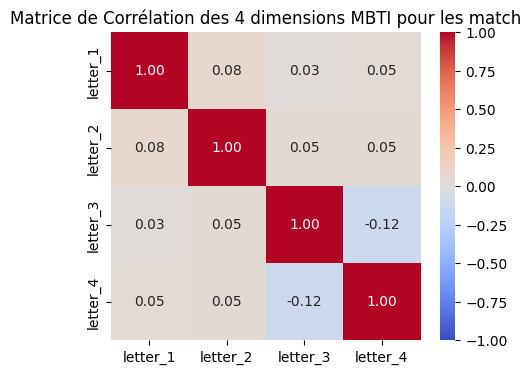

In [35]:
# 1. Définir le mapping pour transformer les lettres en chiffres (0 ou 1)
mapping = {'letter_1': {'E': 1, 'I': 0},
            'letter_2': {'N': 1, 'S': 0},
            'letter_3': {'F': 1, 'T': 0},
            'letter_4': {'P': 1, 'J': 0}}

# 2. Créer une copie des colonnes pour le calcul
actors_mbti_match = mbti_match[['letter_1', 'letter_2', 'letter_3', 'letter_4']].copy()

# Appliquer le mapping
for col, map_dict in mapping.items() :
    actors_mbti_match[col] = actors_mbti_match[col].map(map_dict)

# 3. Calculer la matrice de corrélation
corr_matrix_match = actors_mbti_match.corr()

# 4. Affichage avec une Heatmap (carte de chaleur)
plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix_match, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, center=0)
plt.title("Matrice de Corrélation des 4 dimensions MBTI pour les match")
plt.show()

In [36]:
def cramers_v(contingency_table, chi2) :
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    # Formule simplifiée pour du 2x2
    return np.sqrt(phi2 / min(k - 1, r - 1))

dims = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

for i in range(len(dims)) :
    for j in range(i+1, len(dims)) :
        contingency_table = pd.crosstab(mbti_match[dims[i]], mbti_match[dims[j]])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        v = cramers_v(contingency_table, chi2)
        print(f"Test Chi2 {dims[i]}-{dims[j]} | p-value: {p:.4f} | V de Cramér: {v:.4f}")

        #print(f"Test Chi2 entre Lettre {i+1} et {j+1} - p-value : {p:.4f}")

Test Chi2 letter_1-letter_2 | p-value: 0.0003 | V de Cramér: 0.0744
Test Chi2 letter_1-letter_3 | p-value: 0.1604 | V de Cramér: 0.0286
Test Chi2 letter_1-letter_4 | p-value: 0.0283 | V de Cramér: 0.0446
Test Chi2 letter_2-letter_3 | p-value: 0.0102 | V de Cramér: 0.0523
Test Chi2 letter_2-letter_4 | p-value: 0.0130 | V de Cramér: 0.0505
Test Chi2 letter_3-letter_4 | p-value: 0.0000 | V de Cramér: 0.1167


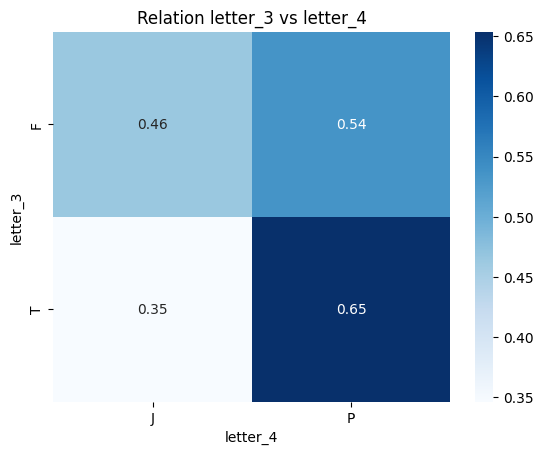

In [37]:
table = pd.crosstab(mbti_match['letter_3'], mbti_match['letter_4'], normalize='index')

sns.heatmap(table, annot=True, cmap='Blues')
plt.title("Relation letter_3 vs letter_4")
plt.show()

### Graph 

In [38]:
# On garde les colonnes voulues + l'index
cols_to_keep = ['letter_1', 'letter_2', 'letter_3', 'letter_4']

# 'index' crée un dictionnaire de type {nom: {col1: val1, col2: val2...}}
mbti_unique = mbti.drop_duplicates(subset=['name_cleaned'], keep='first')

# 2. Maintenant on peut créer le dictionnaire sans erreur
mbti_dict = mbti_unique.set_index('name_cleaned')[cols_to_keep].to_dict(orient='index')

for actor in G.nodes() :
    # mbti_data sera soit le dict des 4 lettres, soit None
    mbti_data = mbti_dict.get(actor) 
    
    if mbti_data :
        # On injecte directement les 4 clés/valeurs dans le noeud
        G.nodes[actor].update(mbti_data)
        
        #full_type = "".join([mbti_data[f'letter_{i}'] for i in range(1, 5)])
        #G.nodes[actor]['mbti_full'] = full_type

# Vérifier
actors_with_mbti = [(n, d['letter_1']) for n, d in G.nodes(data=True) if 'letter_1' in d]
print(f"\nActeurs du graphe avec MBTI : {len(actors_with_mbti)}")
print("\nExemples :")
for name, mbti_type in actors_with_mbti[:10] :
    print(f"  {name:<30} : {mbti_type}")


Acteurs du graphe avec MBTI : 2446

Exemples :
  Sam Worthington                : I
  Zoe Saldana                    : I
  Sigourney Weaver               : I
  Stephen Lang                   : I
  Michelle Rodriguez             : E
  Giovanni Ribisi                : I
  Laz Alonso                     : E
  Johnny Depp                    : I
  Orlando Bloom                  : I
  Keira Knightley                : E
